
Random Forest
Qc_kW: R2=0.9904, RMSE=53.9297, MAE=17.5008
Qr_kW: R2=0.9912, RMSE=52.7010, MAE=14.8693
xD_Benzene: R2=0.7406, RMSE=0.0254, MAE=0.0176
xB_Toluene: R2=0.9475, RMSE=0.0245, MAE=0.0174

SVM
Qc_kW: R2=0.9880, RMSE=60.4079, MAE=28.6225
Qr_kW: R2=0.9880, RMSE=61.3608, MAE=29.3514
xD_Benzene: R2=0.9765, RMSE=0.0076, MAE=0.0054
xB_Toluene: R2=0.9913, RMSE=0.0099, MAE=0.0070

Neural Network
Qc_kW: R2=0.9906, RMSE=53.3612, MAE=17.8592
Qr_kW: R2=0.9913, RMSE=52.3972, MAE=18.3719
xD_Benzene: R2=0.9910, RMSE=0.0047, MAE=0.0032
xB_Toluene: R2=0.9945, RMSE=0.0080, MAE=0.0046


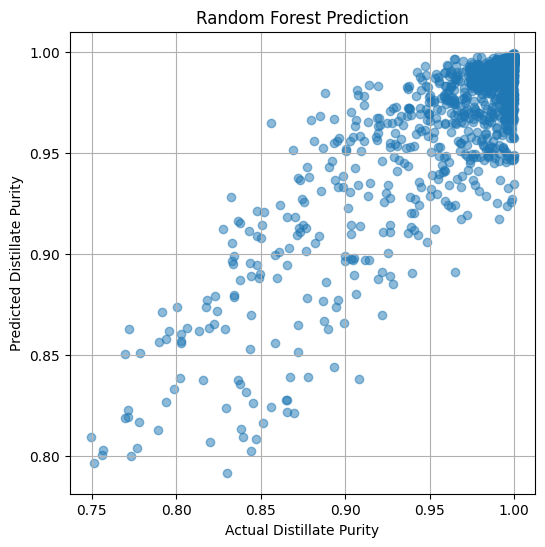

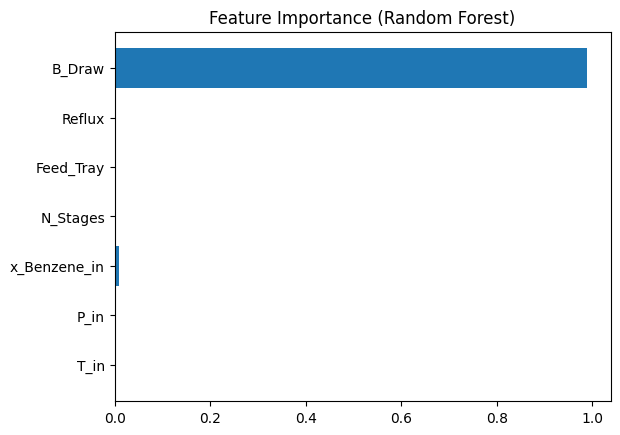

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegresson
df = pd.read_csv('DWSIM_ML_Dataset_Final.csv')
df = df.dropna()
df = df[(df['Qc_kW'] != 0) & (df['Qr_kW'] != 0)]
X = df[['T_in', 'P_in', 'x_Benzene_in', 'N_Stages', 'Feed_Tray', 'Reflux', 'B_Draw']]
Y = df[['Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

rf = RandomForestRegressor(n_estimators=150, random_state=42)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)
svm = MultiOutputRegressor(SVR(kernel='rbf', C=10))
svm.fit(X_train_scaled, Y_train_scaled)
svm_pred_scaled = svm.predict(X_test_scaled)
svm_pred = scaler_Y.inverse_transform(svm_pred_scaled)
nn = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1500, random_state=42)
nn.fit(X_train_scaled, Y_train_scaled)
nn_pred_scaled = nn.predict(X_test_scaled)
nn_pred = scaler_Y.inverse_transform(nn_pred_scaled)
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    r2 = r2_score(y_true, y_pred, multioutput='raw_values')
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')

    outputs = ['Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene']

    for i, out in enumerate(outputs):
        print(f"{out}: R2={r2[i]:.4f}, RMSE={rmse[i]:.4f}, MAE={mae[i]:.4f}")
evaluate(Y_test.values, rf_pred, "Random Forest")
evaluate(Y_test.values, svm_pred, "SVM")
evaluate(Y_test.values, nn_pred, "Neural Network")
#  PLOT
plt.figure(figsize=(6,6))
plt.scatter(Y_test['xD_Benzene'], rf_pred[:,2], alpha=0.5)
plt.xlabel("Actual Distillate Purity")
plt.ylabel("Predicted Distillate Purity")
plt.title("Random Forest Prediction")
plt.grid()
plt.show()
importance = rf.feature_importances_
features = X.columns
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
print(df.columns)

Index(['Run', 'T_in', 'P_in', 'x_Benzene_in', 'N_Stages', 'Feed_Tray',
       'Reflux', 'B_Draw', 'Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene'],
      dtype='object')


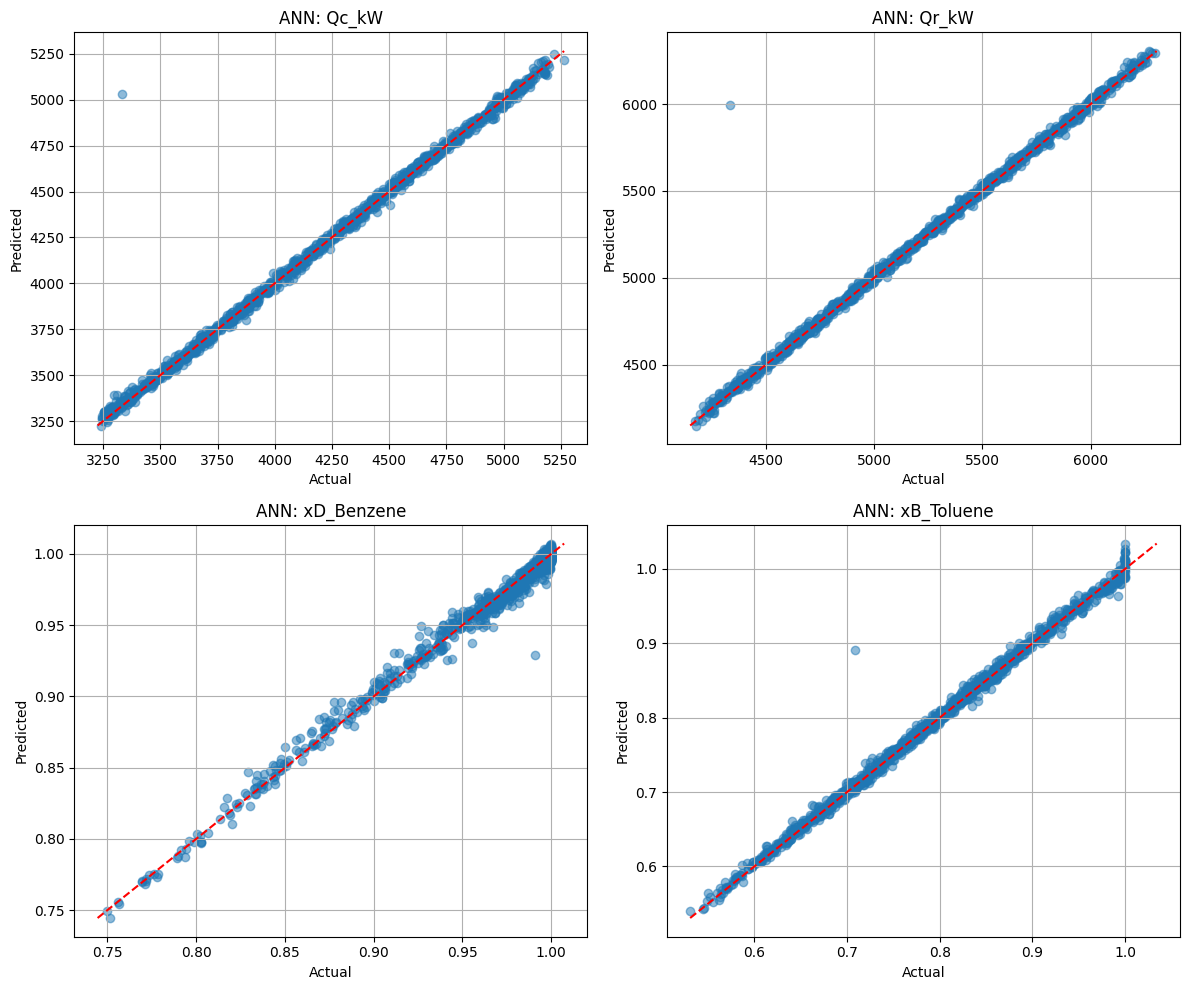

In [ ]:
import matplotlib.pyplot as plt

outputs = ['Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene']

plt.figure(figsize=(12,10))

for i in range(4):
    plt.subplot(2,2,i+1)

    actual = Y_test.iloc[:, i]
    predicted = nn_pred[:, i]

    plt.scatter(actual, predicted, alpha=0.5)

    # perfect line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"ANN: {outputs[i]}")
    plt.grid()

plt.tight_layout()
plt.show()

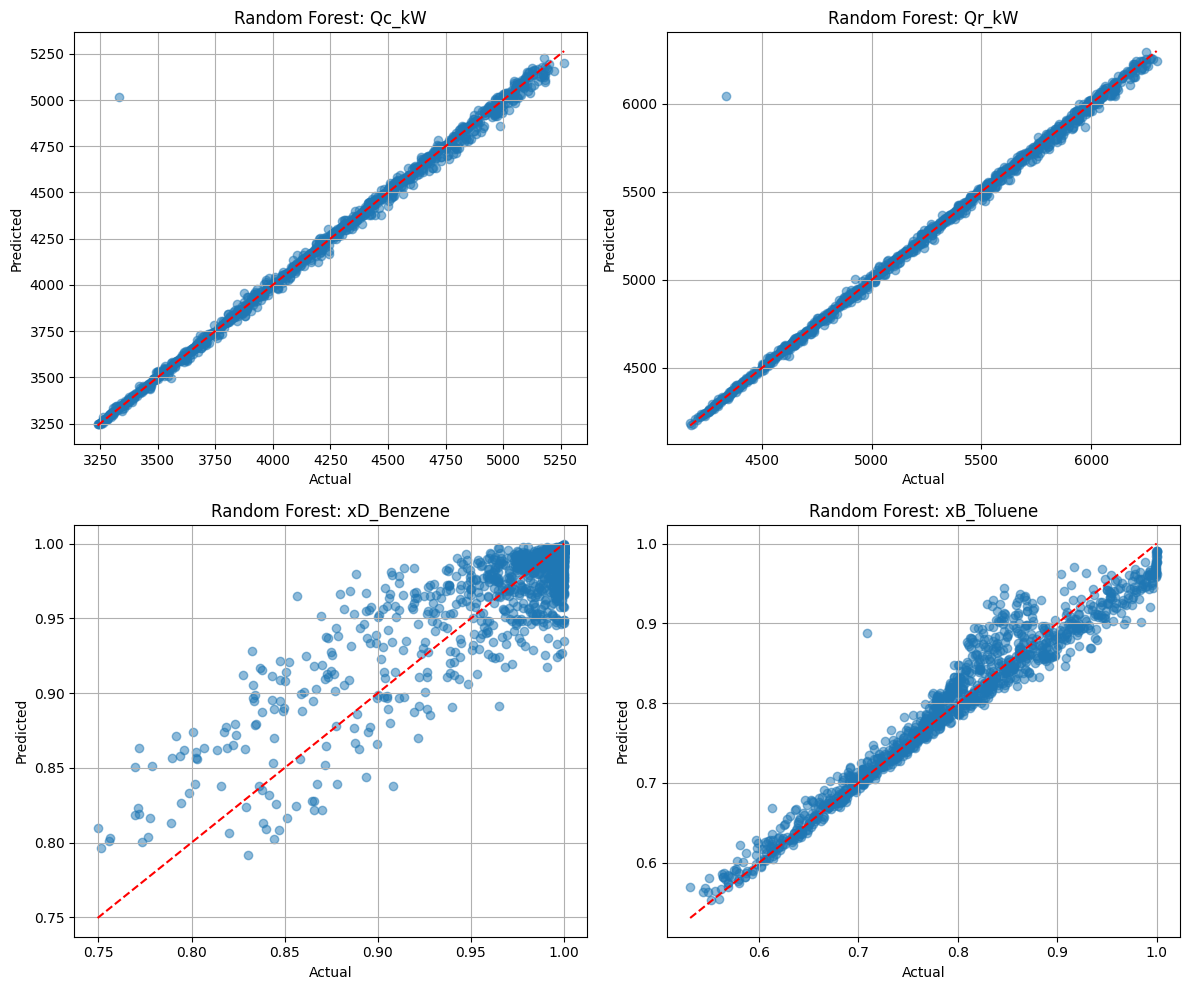

In [ ]:
outputs = ['Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene']

plt.figure(figsize=(12,10))

for i in range(4):
    plt.subplot(2,2,i+1)

    actual = Y_test.iloc[:, i]
    predicted = rf_pred[:, i]

    plt.scatter(actual, predicted, alpha=0.5)

    # perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Random Forest: {outputs[i]}")
    plt.grid()

plt.tight_layout()
plt.show()

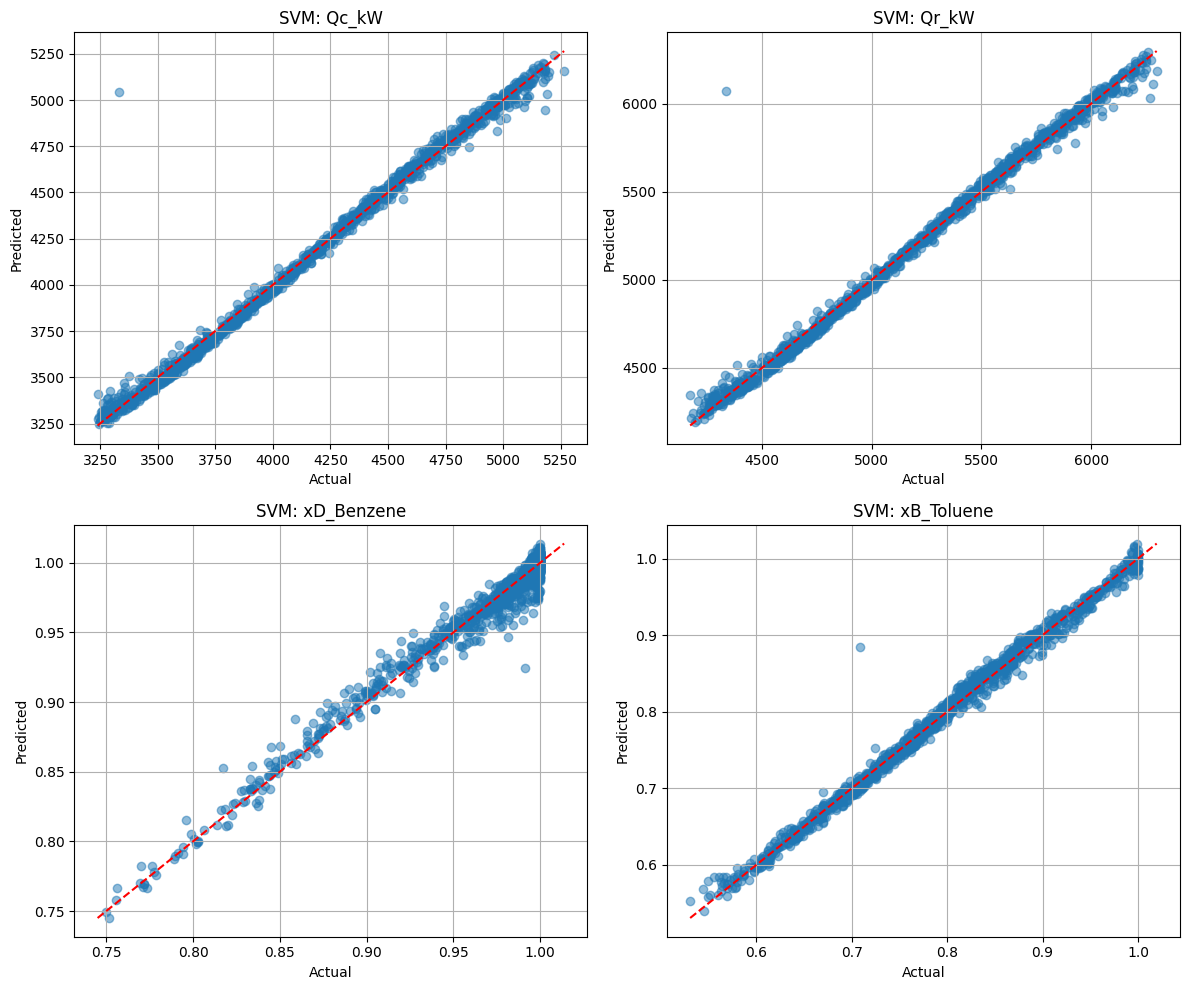

In [ ]:
outputs = ['Qc_kW', 'Qr_kW', 'xD_Benzene', 'xB_Toluene']

plt.figure(figsize=(12,10))

for i in range(4):
    plt.subplot(2,2,i+1)

    actual = Y_test.iloc[:, i]
    predicted = svm_pred[:, i]

    plt.scatter(actual, predicted, alpha=0.5)

    # perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"SVM: {outputs[i]}")
    plt.grid()

plt.tight_layout()
plt.show()